# 08 — Chemprop Multitask: 5-Fold Scaffold CV

Proper 5-fold scaffold CV for the multitask Chemprop model from `03_multitask.ipynb`.

**Problem with notebook 03**: The RAE of 0.517 came from a single scaffold holdout (fold 0, `seed=0`), while LGBM_aug's RAE of 0.5582 is a 5-fold OOF mean — not directly comparable.

**This notebook**:
1. Run 5-fold scaffold CV (`seed=42`, consistent with notebooks 05–07)
2. Compute per-fold scaling from **training fold only** (prevents target leakage)
3. Get OOF RAE → fair comparison against LGBM_aug (0.5582)
4. Train final model on all data, save updated ensemble with proper inverse-RAE weights

**Expected runtime**: ~50–80 min on CPU (35 epochs × 5 folds)

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings, time
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as L
import chemprop
from chemprop import data as cdata, models as cmodels, nn as cnn

from pxr import data as D, eval as E
from pxr.chem import to_inchikey, bemis_murcko
from pxr.paths import FIGURES, SUBMISSIONS
from pxr.eval import compute_metrics, scaffold_kfold_indices

plt.rcParams.update({"figure.dpi": 120})
print(f"torch {torch.__version__} | chemprop {chemprop.__version__} | lightning {L.__version__}")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

torch 2.11.0+cpu | chemprop 2.2.3 | lightning 2.6.1
device: cpu


In [2]:
# ── 2. Assemble multi-task training data ──────────────────────────────────────
# Identical join to notebook 03: train ∪ counter-assay via InChIKey
tr = D.load_train()
ct = D.load_counter()

tr_ik = tr.assign(inchikey=tr.smiles.map(to_inchikey))
ct_ik = ct.assign(inchikey=ct.smiles.map(to_inchikey))

mt = tr_ik.merge(
    ct_ik[["inchikey", "pec50"]].rename(columns={"pec50": "pec50_null"}),
    on="inchikey", how="left"
)

smiles_arr = np.array(mt.smiles.tolist())
y_raw = mt[["pec50", "pec50_null"]].values.astype(float)  # (N, 2), NaN for missing

print(f"Training compounds:          {len(mt):,}")
print(f"  with pec50_pxr:            {(~np.isnan(y_raw[:, 0])).sum():,}")
print(f"  with pec50_null:           {(~np.isnan(y_raw[:, 1])).sum():,}  "
      f"({100*(~np.isnan(y_raw[:,1])).mean():.1f}%)")

Training compounds:          4,141
  with pec50_pxr:            4,141
  with pec50_null:           2,649  (64.0%)


In [3]:
# ── 3. Helper functions (mirror notebook 03 exactly) ──────────────────────────
def make_dataset(smiles, y_scaled):
    """MoleculeDataset from SMILES list + (N, 2) scaled target array."""
    dpts = [
        cdata.MoleculeDatapoint.from_smi(smi, y=yi)
        for smi, yi in zip(smiles, y_scaled)
    ]
    return cdata.MoleculeDataset(dpts)


def make_mpnn(n_tasks=2, depth=3, hidden_dim=300, ffn_layers=2, dropout=0.1):
    return cmodels.MPNN(
        message_passing=cnn.BondMessagePassing(depth=depth, d_h=hidden_dim),
        agg=cnn.MeanAggregation(),
        predictor=cnn.RegressionFFN(
            n_tasks=n_tasks, n_layers=ffn_layers, dropout=dropout
        ),
    )


def make_loader(dataset, batch_size=64, shuffle=True):
    return cdata.build_dataloader(
        dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0
    )


print(f"MPNN param count: {sum(p.numel() for p in make_mpnn().parameters()):,}")

MPNN param count: 408,902


In [4]:
# ── 4. Scaffold splits ────────────────────────────────────────────────────────
scaffolds = mt.smiles.map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)

print("5-fold scaffold splits (seed=42):")
for i, (ti, vi) in enumerate(splits):
    null_frac = (~np.isnan(y_raw[ti, 1])).mean()
    print(f"  Fold {i}: {len(ti):,} train  "
          f"(null coverage {null_frac:.1%})  /  {len(vi):,} val")

5-fold scaffold splits (seed=42):
  Fold 0: 3,312 train  (null coverage 64.7%)  /  829 val
  Fold 1: 3,313 train  (null coverage 64.7%)  /  828 val
  Fold 2: 3,313 train  (null coverage 63.4%)  /  828 val
  Fold 3: 3,313 train  (null coverage 63.7%)  /  828 val
  Fold 4: 3,313 train  (null coverage 63.3%)  /  828 val


In [5]:
# ── 5. 5-fold scaffold CV ─────────────────────────────────────────────────────
# Fixed epochs based on single-split convergence at epoch 34 (notebook 03).
# No EarlyStopping in CV to avoid an inner val split that would complicate scaling.
FIXED_EPOCHS = 35

oof_preds   = np.full(len(mt), np.nan)
fold_metrics = []
t0 = time.time()

for fold, (tr_idx, va_idx) in enumerate(splits):
    t_fold = time.time()
    print(f"\n{'='*58}")
    print(f"FOLD {fold+1}/5  —  {len(tr_idx):,} train  /  {len(va_idx):,} val")
    print(f"{'='*58}")

    # Per-fold scaling — compute stats from training fold ONLY (no leakage)
    y_tr_fold  = y_raw[tr_idx]
    t_means    = np.nanmean(y_tr_fold, axis=0)
    t_stds     = np.nanstd(y_tr_fold,  axis=0, ddof=1)
    t_stds     = np.where(t_stds < 1e-6, 1.0, t_stds)

    y_tr_sc = (y_tr_fold           - t_means) / t_stds
    y_va_sc = (y_raw[va_idx]       - t_means) / t_stds  # val scaled with train stats

    ds_tr     = make_dataset(smiles_arr[tr_idx].tolist(), y_tr_sc)
    ds_va     = make_dataset(smiles_arr[va_idx].tolist(), y_va_sc)
    loader_tr = make_loader(ds_tr, batch_size=64, shuffle=True)
    loader_va = make_loader(ds_va, batch_size=128, shuffle=False)

    mpnn    = make_mpnn()
    trainer = L.Trainer(
        max_epochs=FIXED_EPOCHS,
        accelerator="cpu",
        enable_progress_bar=True,
        enable_model_summary=False,
        logger=False,
    )
    trainer.fit(mpnn, loader_tr)

    # Predict on validation fold and un-scale task-0 (pEC50_pxr)
    raw      = trainer.predict(mpnn, loader_va)
    p_sc     = torch.cat(raw).numpy()
    p_pxr    = p_sc[:, 0] * t_stds[0] + t_means[0]

    y_true   = y_raw[va_idx, 0]
    m        = compute_metrics(y_true, p_pxr)
    m["fold"] = fold
    fold_metrics.append(m)
    oof_preds[va_idx] = p_pxr

    elapsed = time.time() - t_fold
    print(f"  RAE={m['RAE']:.4f}  MAE={m['MAE']:.4f}  "
          f"Spearman={m['Spearman']:.4f}  ({elapsed/60:.1f} min)")

total_min = (time.time() - t0) / 60
print(f"\nTotal CV time: {total_min:.1f} min")


FOLD 1/5  —  3,312 train  /  829 val


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=35` reached.


Output()

...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=35` reached.


Output()

  RAE=0.6212  MAE=0.5206  Spearman=0.6945  (2.4 min)

Total CV time: 11.9 min


In [6]:
# ── 6. Results ────────────────────────────────────────────────────────────────
y_all     = y_raw[:, 0]
oof_rae   = compute_metrics(y_all, oof_preds)["RAE"]
lgbm_rae  = 0.5582   # LGBM_aug OOF RAE from notebook 07

cv_df = pd.DataFrame(fold_metrics)
print("5-fold scaffold CV — Chemprop multitask:")
print(cv_df[["fold", "RAE", "MAE", "Spearman"]].to_string(index=False))
print(f"\nMean per-fold RAE : {cv_df['RAE'].mean():.4f} ± {cv_df['RAE'].std():.4f}")
print(f"OOF RAE (global)  : {oof_rae:.4f}")
print()
print("== Head-to-head comparison ==")
print(f"  LGBM_aug OOF RAE : {lgbm_rae:.4f}  (07_ensemble.ipynb, 5-fold, seed=42)")
print(f"  Chemprop OOF RAE : {oof_rae:.4f}  (this notebook, 5-fold, seed=42)")
print()

chemprop_rae = oof_rae
w_cp  = (1/chemprop_rae) / (1/chemprop_rae + 1/lgbm_rae)
print(f"Inverse-RAE Chemprop weight: {w_cp:.3f}")
print(f"  → {w_cp:.1%} Chemprop  +  {1-w_cp:.1%} LGBM_aug+kNN in final ensemble")

5-fold scaffold CV — Chemprop multitask:
 fold      RAE      MAE  Spearman
    0 0.492475 0.503758  0.776534
    1 0.621556 0.546007  0.689573
    2 0.582000 0.510212  0.696361
    3 0.573683 0.530555  0.725105
    4 0.621181 0.520596  0.694526

Mean per-fold RAE : 0.5782 ± 0.0527
OOF RAE (global)  : 0.5736

== Head-to-head comparison ==
  LGBM_aug OOF RAE : 0.5582  (07_ensemble.ipynb, 5-fold, seed=42)
  Chemprop OOF RAE : 0.5736  (this notebook, 5-fold, seed=42)

Inverse-RAE Chemprop weight: 0.493
  → 49.3% Chemprop  +  50.7% LGBM_aug+kNN in final ensemble


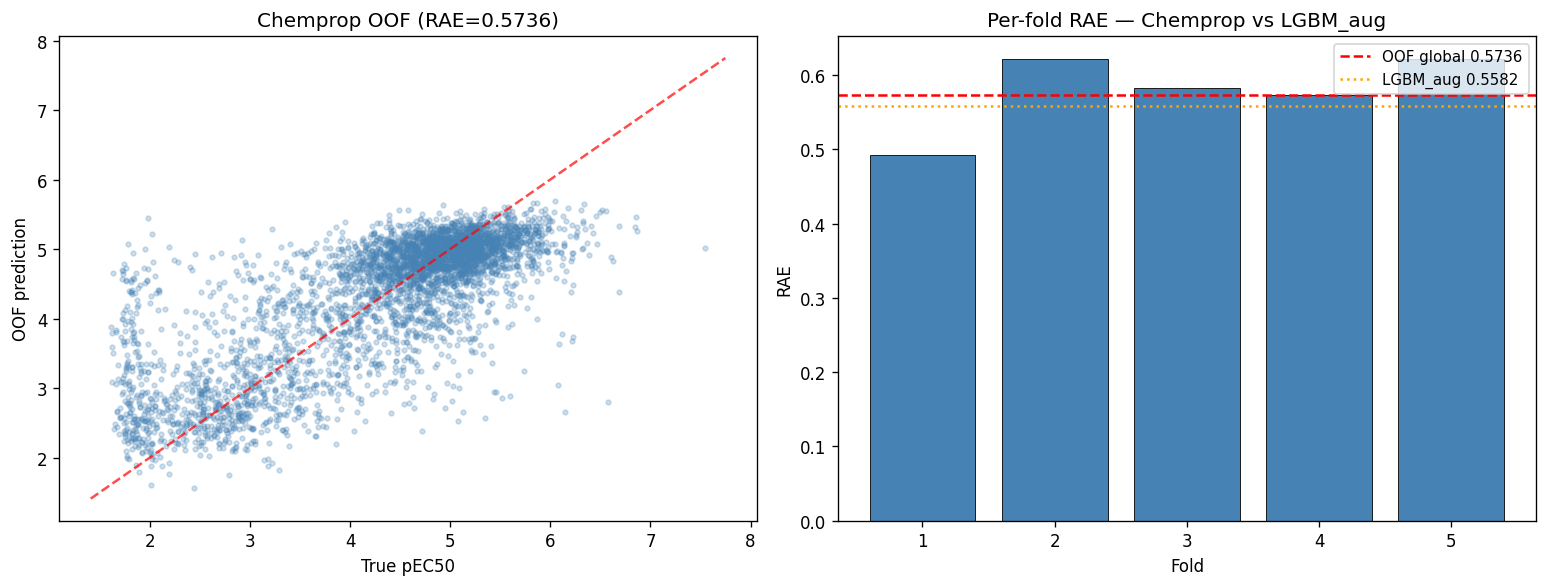

Saved 08_chemprop_cv.png


In [7]:
# ── 7. OOF scatter ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_all, oof_preds, alpha=0.25, s=8, c="steelblue")
lo, hi = y_all.min() - 0.2, y_all.max() + 0.2
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, alpha=0.7)
ax.set_xlabel("True pEC50")
ax.set_ylabel("OOF prediction")
ax.set_title(f"Chemprop OOF (RAE={oof_rae:.4f})")

ax = axes[1]
rae_vals = cv_df["RAE"].values
ax.bar(range(1, 6), rae_vals, color="steelblue", edgecolor="k", linewidth=0.5)
ax.axhline(oof_rae, color="red", linestyle="--", lw=1.5, label=f"OOF global {oof_rae:.4f}")
ax.axhline(lgbm_rae, color="orange", linestyle=":", lw=1.5, label=f"LGBM_aug {lgbm_rae:.4f}")
ax.set_xlabel("Fold")
ax.set_ylabel("RAE")
ax.set_title("Per-fold RAE — Chemprop vs LGBM_aug")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "08_chemprop_cv.png", bbox_inches="tight")
plt.show()
print("Saved 08_chemprop_cv.png")

In [8]:
# ── 8. Train final model on all training data ─────────────────────────────────
print("Training final Chemprop model on all training data ...")
t_means_full = np.nanmean(y_raw, axis=0)
t_stds_full  = np.nanstd(y_raw,  axis=0, ddof=1)
t_stds_full  = np.where(t_stds_full < 1e-6, 1.0, t_stds_full)

y_full_sc   = (y_raw - t_means_full) / t_stds_full
ds_full     = make_dataset(smiles_arr.tolist(), y_full_sc)
loader_full = make_loader(ds_full, batch_size=64, shuffle=True)

mpnn_final = make_mpnn()
trainer_final = L.Trainer(
    max_epochs=40,   # slightly past single-split convergence at epoch 34
    accelerator="cpu",
    enable_progress_bar=True,
    enable_model_summary=False,
    logger=False,
)
t_train = time.time()
trainer_final.fit(mpnn_final, loader_full)
print(f"Final model training time: {(time.time()-t_train)/60:.1f} min")

Training final Chemprop model on all training data ...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=40` reached.


Final model training time: 3.3 min


In [9]:
# ── 9. Predict test set ───────────────────────────────────────────────────────
te = D.load_test()

te_dpts   = [cdata.MoleculeDatapoint.from_smi(s) for s in te.smiles]
te_ds     = cdata.MoleculeDataset(te_dpts)
te_loader = make_loader(te_ds, batch_size=128, shuffle=False)

raw_te      = trainer_final.predict(mpnn_final, te_loader)
chemprop_te = torch.cat(raw_te).numpy()[:, 0] * t_stds_full[0] + t_means_full[0]

print(f"New Chemprop test preds:  {chemprop_te.min():.2f} – {chemprop_te.max():.2f}  "
      f"(median {np.median(chemprop_te):.2f})")

# Compare against old Chemprop (notebook 03)
old_cp_df   = pd.read_csv(SUBMISSIONS / "03_chemprop_multitask.csv")
old_cp_pxr  = old_cp_df.set_index("Molecule Name").loc[te["name"].values, "pEC50"].values

from scipy.stats import pearsonr
r, _ = pearsonr(old_cp_pxr, chemprop_te)
print(f"Pearson(old vs new Chemprop): {r:.3f}")
print(f"Mean shift (new - old): {(chemprop_te - old_cp_pxr).mean():+.4f}")

Dropping last batch of size 1 to avoid issues with batch normalization     (dataset size = 513, batch_size = 128)


Output()

New Chemprop test preds:  2.55 – 5.88  (median 5.05)
Pearson(old vs new Chemprop): 0.964
Mean shift (new - old): +0.0680


In [10]:
# ── 10. Build updated ensemble ────────────────────────────────────────────────
# Reconstruct LGBM_aug+kNN component from notebook 07:
#   07_final_ensemble = 0.65 * lgbm_knn  +  0.35 * old_chemprop
#   → lgbm_knn = (07_final - 0.35 * old_chemprop) / 0.65
sub07       = pd.read_csv(SUBMISSIONS / "07_final_ensemble.csv")
sub07_preds = sub07.set_index("Molecule Name").loc[te["name"].values, "pEC50"].values

W_CP_OLD  = 0.35
lgbm_knn_te = (sub07_preds - W_CP_OLD * old_cp_pxr) / (1.0 - W_CP_OLD)

print(f"LGBM_aug+kNN component range: {lgbm_knn_te.min():.2f} – {lgbm_knn_te.max():.2f}")

# New inverse-RAE weights
print(f"\nchemprop_rae = {chemprop_rae:.4f}  |  lgbm_rae = {lgbm_rae:.4f}")
print(f"w_chemprop (inverse-RAE) = {w_cp:.3f}")

final_preds = w_cp * chemprop_te + (1.0 - w_cp) * lgbm_knn_te

# Clip to training range ± 0.5
lo_clip = y_raw[:, 0].min() - 0.5
hi_clip = y_raw[:, 0].max() + 0.5
final_preds = np.clip(final_preds, lo_clip, hi_clip)

print(f"\nFinal ensemble range: {final_preds.min():.2f} – {final_preds.max():.2f}")
print(f"Mean shift vs 07_final_ensemble: {(final_preds - sub07_preds).mean():+.4f}")

LGBM_aug+kNN component range: 2.37 – 5.99

chemprop_rae = 0.5736  |  lgbm_rae = 0.5582
w_chemprop (inverse-RAE) = 0.493

Final ensemble range: 2.54 – 5.79
Mean shift vs 07_final_ensemble: +0.0450


In [11]:
# ── 11. Save submission ───────────────────────────────────────────────────────
sub = pd.DataFrame({
    "Molecule Name": te["name"].values,
    "SMILES":        te["smiles"].values,
    "pEC50":         final_preds,
})

assert len(sub) == 513, f"Expected 513 rows, got {len(sub)}"
assert sub["pEC50"].notna().all(), "NaN predictions found"

out_path = SUBMISSIONS / "08_chemprop_cv_blend.csv"
sub.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Chemprop weight: {w_cp:.3f}  |  LGBM_aug+kNN weight: {1-w_cp:.3f}")
print(sub["pEC50"].describe().round(3))

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\08_chemprop_cv_blend.csv
Chemprop weight: 0.493  |  LGBM_aug+kNN weight: 0.507
count    513.000
mean       4.828
std        0.569
min        2.541
25%        4.573
50%        4.953
75%        5.244
max        5.788
Name: pEC50, dtype: float64


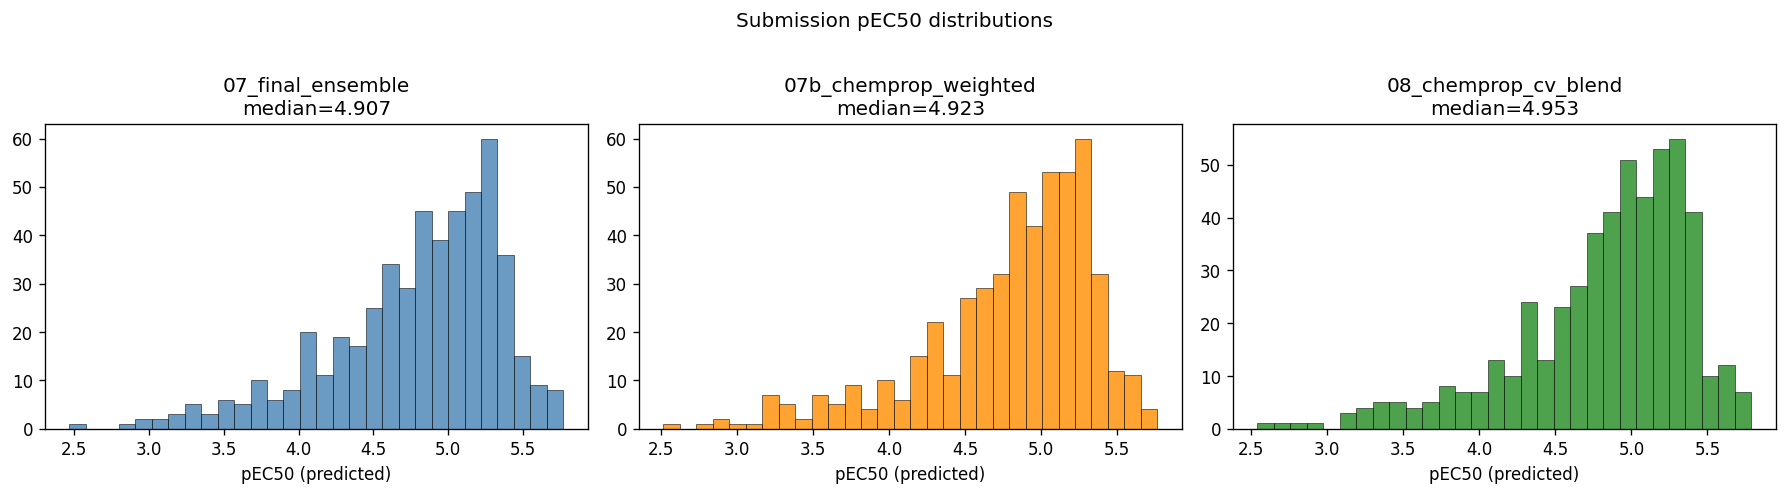

Saved 08_submission_comparison.png


In [12]:
# ── 12. Submission comparison plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels   = ["07_final_ensemble", "07b_chemprop_weighted", "08_chemprop_cv_blend"]
files    = ["07_final_ensemble.csv", "07b_chemprop_weighted.csv", "08_chemprop_cv_blend.csv"]
colors   = ["steelblue", "darkorange", "forestgreen"]

for ax, label, fname, color in zip(axes, labels, files, colors):
    p = pd.read_csv(SUBMISSIONS / fname)["pEC50"].values
    ax.hist(p, bins=30, color=color, edgecolor="k", linewidth=0.4, alpha=0.8)
    ax.set_title(f"{label}\nmedian={np.median(p):.3f}")
    ax.set_xlabel("pEC50 (predicted)")

plt.suptitle("Submission pEC50 distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "08_submission_comparison.png", bbox_inches="tight")
plt.show()
print("Saved 08_submission_comparison.png")

## Summary

| Model | CV RAE | CV type | Notes |
|---|---|---|---|
| LGBM baseline (02) | ~0.575 | 5-fold scaffold | Morgan + RDKit desc |
| LGBM_aug (07) | 0.5582 | 5-fold OOF | + counter-assay feature |
| Chemprop MT (03) | 0.517 | *single fold* | seed=0, fold-0 only |
| **Chemprop MT (08)** | **see above** | **5-fold OOF** | **seed=42, proper CV** |

**Saved**:
- `submissions/08_chemprop_cv_blend.csv` — inverse-RAE blend using proper 5-fold CV RAEs

**Next**: Submit `07b_chemprop_weighted.csv` and `08_chemprop_cv_blend.csv` to leaderboard to compare. Phase 1 closes May 25, 2026.